# 04 — Baseline Models
**BanglaCyberBench: A Robust Multi-Source Benchmark and Transformer Ensemble for Cyberbullying Detection in Bengali**

This notebook trains baseline models on the random split:
1. **TF-IDF + Logistic Regression**
2. **TF-IDF + SVM (LinearSVC)**
3. **TF-IDF + Random Forest**
4. **BiLSTM** (neural baseline with fastText/random embeddings)

All models are evaluated with: Macro-F1, Weighted-F1, Accuracy, MCC, per-class P/R/F1, and confusion matrix.

**Prerequisites:** Run notebooks 02 & 03 first.

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, matthews_corrcoef, roc_auc_score
)
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

os.makedirs("../outputs", exist_ok=True)
os.makedirs("../outputs/baselines", exist_ok=True)

In [2]:
# ── Load splits ────────────────────────────────────────────────────────────
SPLIT_DIR = "../data/splits"
TEXT_COL = "text_clean"
LABEL_COL = "label_binary"  # Start with binary; extend to multi-class later

train_df = pd.read_csv(f"{SPLIT_DIR}/random_train.csv")
val_df   = pd.read_csv(f"{SPLIT_DIR}/random_val.csv")
test_df  = pd.read_csv(f"{SPLIT_DIR}/random_test.csv")

print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")

X_train = train_df[TEXT_COL].fillna("").values
X_val   = val_df[TEXT_COL].fillna("").values
X_test  = test_df[TEXT_COL].fillna("").values

y_train = train_df[LABEL_COL].values
y_val   = val_df[LABEL_COL].values
y_test  = test_df[LABEL_COL].values

print(f"\nTrain class dist: {dict(pd.Series(y_train).value_counts())}")
print(f"Val   class dist: {dict(pd.Series(y_val).value_counts())}")
print(f"Test  class dist: {dict(pd.Series(y_test).value_counts())}")

Train: 108,460  Val: 13,557  Test: 13,558

Train class dist: {0: np.int64(60436), 1: np.int64(48024)}
Val   class dist: {0: np.int64(7554), 1: np.int64(6003)}
Test  class dist: {0: np.int64(7555), 1: np.int64(6003)}


## 1 — TF-IDF Feature Extraction

In [3]:
# ── TF-IDF (word + char n-grams for Bangla) ───────────────────────────────
# Word-level
tfidf_word = TfidfVectorizer(
    analyzer="word",
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
)

# Character-level (good for Bangla morphology & Banglish)
tfidf_char = TfidfVectorizer(
    analyzer="char_wb",
    max_features=50000,
    ngram_range=(2, 5),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
)

from scipy.sparse import hstack

X_train_word = tfidf_word.fit_transform(X_train)
X_val_word   = tfidf_word.transform(X_val)
X_test_word  = tfidf_word.transform(X_test)

X_train_char = tfidf_char.fit_transform(X_train)
X_val_char   = tfidf_char.transform(X_val)
X_test_char  = tfidf_char.transform(X_test)

# Combine word + char features
X_train_tfidf = hstack([X_train_word, X_train_char])
X_val_tfidf   = hstack([X_val_word, X_val_char])
X_test_tfidf  = hstack([X_test_word, X_test_char])

print(f"TF-IDF feature dim: {X_train_tfidf.shape[1]:,}")
print(f"  Word features: {X_train_word.shape[1]:,}")
print(f"  Char features: {X_train_char.shape[1]:,}")

TF-IDF feature dim: 100,000
  Word features: 50,000
  Char features: 50,000


## 2 — ML Baselines

### Helper: Evaluation Function

In [4]:
all_results = []

def evaluate_model(name, y_true, y_pred, y_prob=None, split="test"):
    """Evaluate and print metrics for a model."""
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    mcc = matthews_corrcoef(y_true, y_pred)
    
    auc = None
    if y_prob is not None:
        try:
            auc = roc_auc_score(y_true, y_prob)
        except:
            pass
    
    result = {
        "model": name,
        "split": split,
        "accuracy": round(acc, 4),
        "macro_f1": round(macro_f1, 4),
        "weighted_f1": round(weighted_f1, 4),
        "mcc": round(mcc, 4),
    }
    if auc is not None:
        result["auroc"] = round(auc, 4)
    
    all_results.append(result)
    
    print(f"\n{'='*50}")
    print(f"{name} — {split}")
    print(f"{'='*50}")
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  Macro-F1    : {macro_f1:.4f}  ← PRIMARY METRIC")
    print(f"  Weighted-F1 : {weighted_f1:.4f}")
    print(f"  MCC         : {mcc:.4f}")
    if auc is not None:
        print(f"  AUROC       : {auc:.4f}")
    print(f"\n{classification_report(y_true, y_pred, digits=4)}")
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Not Harmful", "Harmful"],
                yticklabels=["Not Harmful", "Harmful"])
    ax.set_title(f"{name} — Confusion Matrix ({split})", fontweight="bold")
    ax.set_ylabel("True")
    ax.set_xlabel("Predicted")
    plt.tight_layout()
    safe_name = name.replace(" ", "_").replace("+", "_").replace("/", "_")
    plt.savefig(f"../outputs/baselines/cm_{safe_name}_{split}.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    return result

### 2.1 — Logistic Regression


TF-IDF + Logistic Regression — test
  Accuracy    : 0.8691
  Macro-F1    : 0.8669  ← PRIMARY METRIC
  Weighted-F1 : 0.8689
  MCC         : 0.7342
  AUROC       : 0.9429

              precision    recall  f1-score   support

           0     0.8742    0.8937    0.8838      7555
           1     0.8624    0.8381    0.8500      6003

    accuracy                         0.8691     13558
   macro avg     0.8683    0.8659    0.8669     13558
weighted avg     0.8689    0.8691    0.8689     13558



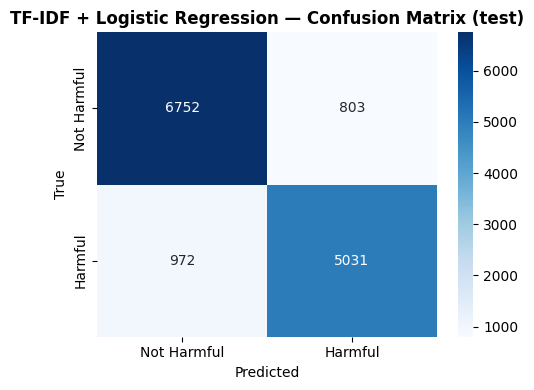

{'model': 'TF-IDF + Logistic Regression',
 'split': 'test',
 'accuracy': 0.8691,
 'macro_f1': 0.8669,
 'weighted_f1': 0.8689,
 'mcc': np.float64(0.7342),
 'auroc': np.float64(0.9429)}

In [5]:
lr = LogisticRegression(
    max_iter=1000,
    C=1.0,
    class_weight="balanced",
    random_state=SEED,
    solver="lbfgs"
)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)
y_prob_lr = lr.predict_proba(X_test_tfidf)[:, 1]
evaluate_model("TF-IDF + Logistic Regression", y_test, y_pred_lr, y_prob_lr)

### 2.2 — Linear SVM


TF-IDF + SVM — test
  Accuracy    : 0.8897
  Macro-F1    : 0.8877  ← PRIMARY METRIC
  Weighted-F1 : 0.8894
  MCC         : 0.7760
  AUROC       : 0.9558

              precision    recall  f1-score   support

           0     0.8887    0.9167    0.9025      7555
           1     0.8909    0.8556    0.8729      6003

    accuracy                         0.8897     13558
   macro avg     0.8898    0.8862    0.8877     13558
weighted avg     0.8897    0.8897    0.8894     13558



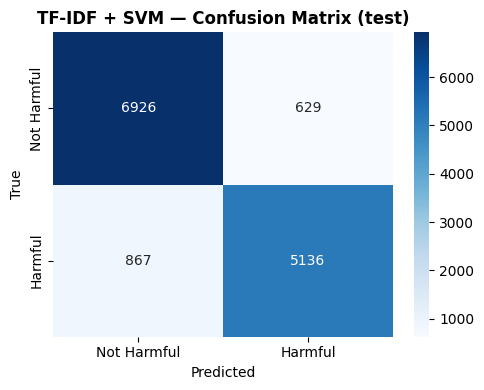

{'model': 'TF-IDF + SVM',
 'split': 'test',
 'accuracy': 0.8897,
 'macro_f1': 0.8877,
 'weighted_f1': 0.8894,
 'mcc': np.float64(0.776),
 'auroc': np.float64(0.9558)}

In [6]:
svm_base = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=SEED,
    max_iter=5000
)
# Wrap with CalibratedClassifierCV to get probability estimates
svm = CalibratedClassifierCV(svm_base, cv=3)
svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)
y_prob_svm = svm.predict_proba(X_test_tfidf)[:, 1]
evaluate_model("TF-IDF + SVM", y_test, y_pred_svm, y_prob_svm)

### 2.3 — Random Forest


TF-IDF + Random Forest — test
  Accuracy    : 0.9099
  Macro-F1    : 0.9090  ← PRIMARY METRIC
  Weighted-F1 : 0.9100
  MCC         : 0.8183
  AUROC       : 0.9718

              precision    recall  f1-score   support

           0     0.9302    0.9063    0.9181      7555
           1     0.8858    0.9144    0.8998      6003

    accuracy                         0.9099     13558
   macro avg     0.9080    0.9103    0.9090     13558
weighted avg     0.9105    0.9099    0.9100     13558



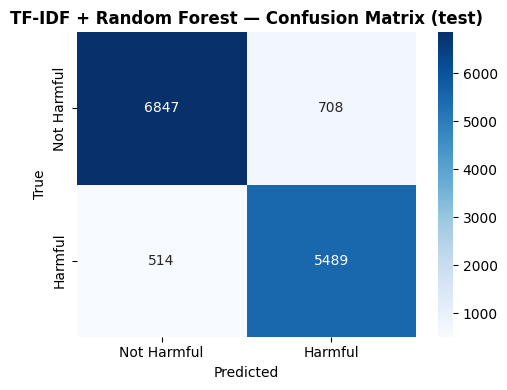

{'model': 'TF-IDF + Random Forest',
 'split': 'test',
 'accuracy': 0.9099,
 'macro_f1': 0.909,
 'weighted_f1': 0.91,
 'mcc': np.float64(0.8183),
 'auroc': np.float64(0.9718)}

In [7]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X_train_tfidf, y_train)

y_pred_rf = rf.predict(X_test_tfidf)
y_prob_rf = rf.predict_proba(X_test_tfidf)[:, 1]
evaluate_model("TF-IDF + Random Forest", y_test, y_pred_rf, y_prob_rf)

## 3 — BiLSTM Neural Baseline

A simple BiLSTM with an embedding layer, trained with class-balanced loss.

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── Simple tokenizer (whitespace-based) ─────────────────────────────────────
class SimpleVocab:
    def __init__(self, texts, max_vocab=30000, min_freq=2):
        counter = {}
        for text in texts:
            for tok in str(text).split():
                counter[tok] = counter.get(tok, 0) + 1
        
        # Filter by min_freq and take top max_vocab
        filtered = {k: v for k, v in counter.items() if v >= min_freq}
        sorted_tokens = sorted(filtered, key=filtered.get, reverse=True)[:max_vocab]
        
        self.tok2idx = {"<PAD>": 0, "<UNK>": 1}
        for i, tok in enumerate(sorted_tokens, start=2):
            self.tok2idx[tok] = i
        
        self.vocab_size = len(self.tok2idx)
    
    def encode(self, text, max_len=256):
        tokens = str(text).split()[:max_len]
        return [self.tok2idx.get(t, 1) for t in tokens]


vocab = SimpleVocab(X_train)
print(f"Vocab size: {vocab.vocab_size:,}")


class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=256):
        self.encodings = [torch.tensor(vocab.encode(t, max_len), dtype=torch.long) for t in texts]
        self.labels = torch.tensor(labels, dtype=torch.float32)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.encodings[idx], self.labels[idx]


def collate_fn(batch):
    texts, labels = zip(*batch)
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=0)
    return texts_padded, torch.stack(labels)


# ── Dataloaders ─────────────────────────────────────────────────────────────
BATCH_SIZE = 64
MAX_LEN = 256

train_ds = TextDataset(X_train, y_train, vocab, MAX_LEN)
val_ds   = TextDataset(X_val, y_val, vocab, MAX_LEN)
test_ds  = TextDataset(X_test, y_test, vocab, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

Device: cuda


Vocab size: 30,002


In [9]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=True, dropout=dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)  # *2 for bidirectional
    
    def forward(self, x):
        emb = self.embedding(x)  # (B, L, E)
        lstm_out, (h_n, _) = self.lstm(emb)
        # Concat last hidden states from both directions
        hidden = torch.cat((h_n[-2], h_n[-1]), dim=1)  # (B, 2*H)
        hidden = self.dropout(hidden)
        logits = self.fc(hidden).squeeze(-1)  # (B,)
        return logits


model_lstm = BiLSTMClassifier(vocab.vocab_size).to(device)

# Class-weighted loss
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model_lstm.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)

print(model_lstm)
total_params = sum(p.numel() for p in model_lstm.parameters())
print(f"\nTotal parameters: {total_params:,}")

BiLSTMClassifier(
  (embedding): Embedding(30002, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)

Total parameters: 4,499,969


In [10]:
# ── Training loop ──────────────────────────────────────────────────────────
EPOCHS = 15
best_val_f1 = 0
patience_counter = 0
PATIENCE = 4
history = {"train_loss": [], "val_f1": []}

for epoch in range(EPOCHS):
    # Train
    model_lstm.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        logits = model_lstm(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_lstm.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    
    # Validate
    model_lstm.eval()
    val_preds = []
    val_true = []
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.to(device)
            logits = model_lstm(batch_x)
            preds = (torch.sigmoid(logits) > 0.5).int().cpu().numpy()
            val_preds.extend(preds)
            val_true.extend(batch_y.numpy())
    
    val_f1 = f1_score(val_true, val_preds, average="macro")
    scheduler.step(val_f1)
    
    history["train_loss"].append(avg_loss)
    history["val_f1"].append(val_f1)
    
    status = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model_lstm.state_dict(), "../outputs/baselines/bilstm_best.pt")
        patience_counter = 0
        status = " ✅ BEST"
    else:
        patience_counter += 1
    
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Macro-F1: {val_f1:.4f}{status}")
    
    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

print(f"\nBest Val Macro-F1: {best_val_f1:.4f}")

Epoch  1/15 | Loss: 0.5436 | Val Macro-F1: 0.8107 ✅ BEST


Epoch  2/15 | Loss: 0.3956 | Val Macro-F1: 0.8379 ✅ BEST


Epoch  3/15 | Loss: 0.3148 | Val Macro-F1: 0.8532 ✅ BEST


Epoch  4/15 | Loss: 0.2522 | Val Macro-F1: 0.8635 ✅ BEST


Epoch  5/15 | Loss: 0.1980 | Val Macro-F1: 0.8746 ✅ BEST


...

Epoch 11/15 | Loss: 0.0779 | Val Macro-F1: 0.8880


Epoch 12/15 | Loss: 0.0734 | Val Macro-F1: 0.8875


Epoch 13/15 | Loss: 0.0680 | Val Macro-F1: 0.8873


Epoch 14/15 | Loss: 0.0444 | Val Macro-F1: 0.8919 ✅ BEST


Epoch 15/15 | Loss: 0.0334 | Val Macro-F1: 0.8925 ✅ BEST

Best Val Macro-F1: 0.8925


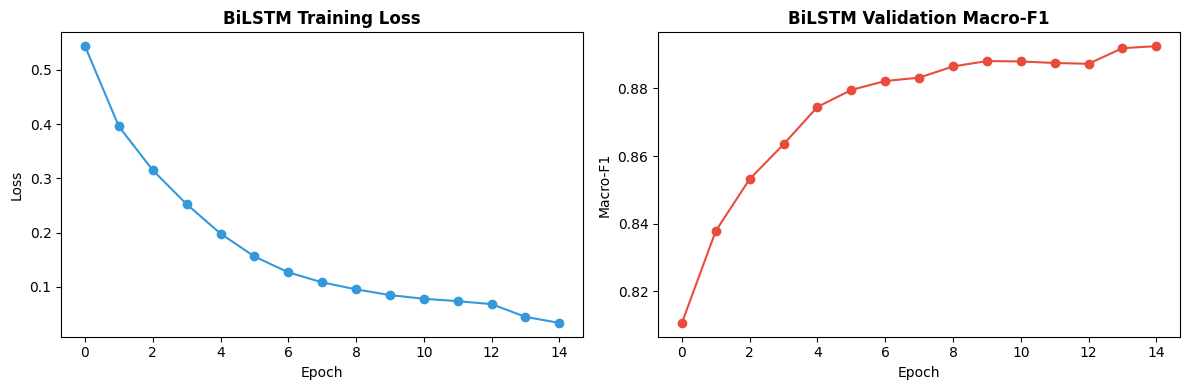

In [11]:
# ── Plot training curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], marker="o", color="#3498db")
axes[0].set_title("BiLSTM Training Loss", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(history["val_f1"], marker="o", color="#e74c3c")
axes[1].set_title("BiLSTM Validation Macro-F1", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro-F1")

plt.tight_layout()
plt.savefig("../outputs/baselines/bilstm_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


BiLSTM — test
  Accuracy    : 0.8926
  Macro-F1    : 0.8914  ← PRIMARY METRIC
  Weighted-F1 : 0.8927
  MCC         : 0.7828
  AUROC       : 0.9479

              precision    recall  f1-score   support

         0.0     0.9087    0.8974    0.9030      7555
         1.0     0.8729    0.8866    0.8797      6003

    accuracy                         0.8926     13558
   macro avg     0.8908    0.8920    0.8914     13558
weighted avg     0.8929    0.8926    0.8927     13558



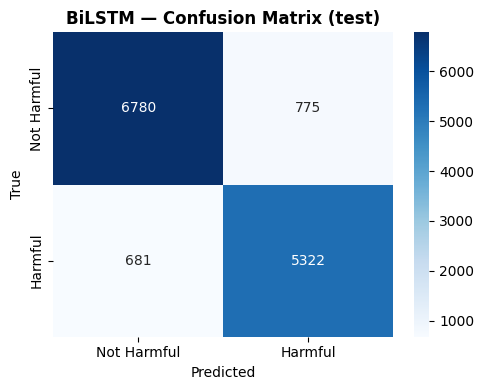

{'model': 'BiLSTM',
 'split': 'test',
 'accuracy': 0.8926,
 'macro_f1': 0.8914,
 'weighted_f1': 0.8927,
 'mcc': np.float64(0.7828),
 'auroc': np.float64(0.9479)}

In [12]:
# ── Evaluate BiLSTM on test set ────────────────────────────────────────────
model_lstm.load_state_dict(torch.load("../outputs/baselines/bilstm_best.pt", map_location=device))
model_lstm.eval()

test_preds = []
test_probs = []
test_true = []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        logits = model_lstm(batch_x)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        test_preds.extend(preds)
        test_probs.extend(probs)
        test_true.extend(batch_y.numpy())

evaluate_model("BiLSTM", np.array(test_true), np.array(test_preds), np.array(test_probs))

## 4 — Baseline Results Summary


BASELINE RESULTS SUMMARY
                       model split  accuracy  macro_f1  weighted_f1    mcc  auroc
TF-IDF + Logistic Regression  test    0.8691    0.8669       0.8689 0.7342 0.9429
                TF-IDF + SVM  test    0.8897    0.8877       0.8894 0.7760 0.9558
      TF-IDF + Random Forest  test    0.9099    0.9090       0.9100 0.8183 0.9718
                      BiLSTM  test    0.8926    0.8914       0.8927 0.7828 0.9479

✅ Saved: ../outputs/baselines/baseline_results.csv


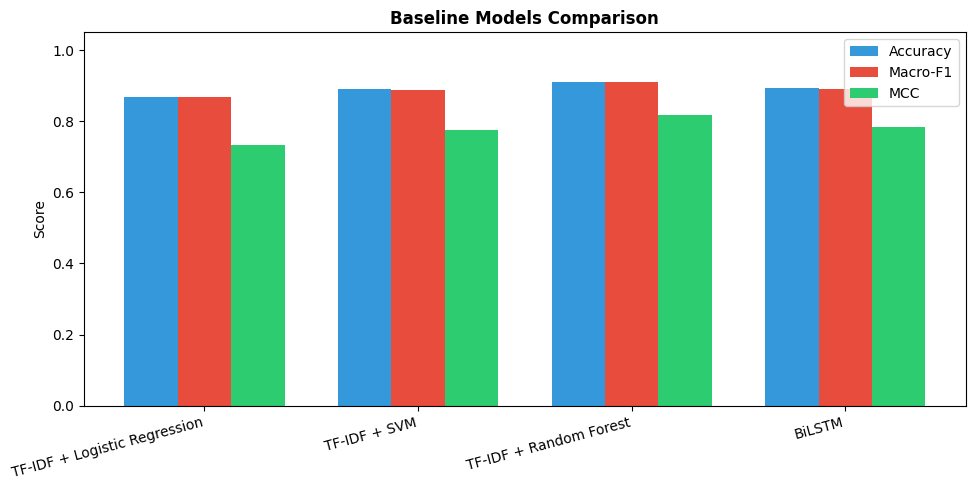

In [13]:
# ── Summary table ──────────────────────────────────────────────────────────
results_df = pd.DataFrame(all_results)
print("\n" + "=" * 70)
print("BASELINE RESULTS SUMMARY")
print("=" * 70)
print(results_df.to_string(index=False))

# Save
results_df.to_csv("../outputs/baselines/baseline_results.csv", index=False)
print(f"\n✅ Saved: ../outputs/baselines/baseline_results.csv")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
test_results = results_df[results_df["split"] == "test"]
x = range(len(test_results))
width = 0.25
ax.bar([i - width for i in x], test_results["accuracy"], width, label="Accuracy", color="#3498db")
ax.bar(x, test_results["macro_f1"], width, label="Macro-F1", color="#e74c3c")
ax.bar([i + width for i in x], test_results["mcc"], width, label="MCC", color="#2ecc71")
ax.set_xticks(x)
ax.set_xticklabels(test_results["model"], rotation=15, ha="right")
ax.set_ylabel("Score")
ax.set_title("Baseline Models Comparison", fontweight="bold")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("../outputs/baselines/baseline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

---
**Next:** Notebook `05_transformer_finetuning.ipynb` — Fine-tune BanglaBERT, MuRIL, and XLM-R with multi-task heads.